# Phase 4: Metadata Creation

**Notebook:** `04_create_metadata.ipynb`  
**Matching module:** `03_ingestion/04_create_metadata.py`

**Purpose:** Attach document name, title, department, content category, page range, source file, provenance method, confidence, and safety labels to every retrieval chunk.

## Input and output contract

**Primary input:** `01_data/processed/03_text_chunks.json`.  
**Page-reference input:** original PDFs under `01_data/raw/`.

**Data outputs:** `04_metadata.json`, `04_enriched_chunks.json`, `04_metadata_report.json`, `04_metadata_audit.csv`, and `04_unresolved_metadata.json`.

**Plot outputs:** `plots/04_metadata_field_coverage.png` and `plots/04_chunks_by_department.png`.

In [8]:
from __future__ import annotations

import importlib.util
import json
import sys
from pathlib import Path

from IPython.display import Image, display


def find_project_root(start: Path) -> Path:
    """Locate the project from Jupyter or repository execution."""
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "03_ingestion" / "04_create_metadata.py").is_file():
            return candidate
        nested = candidate / "hospital_patient_helpdesk_chatbot"
        if (nested / "03_ingestion" / "04_create_metadata.py").is_file():
            return nested
    raise FileNotFoundError("Could not locate hospital_patient_helpdesk_chatbot.")


PROJECT_ROOT = find_project_root(Path.cwd())
PROCESSED_DATA_DIR = PROJECT_ROOT / "01_data" / "processed"
RAW_DATA_DIR = PROJECT_ROOT / "01_data" / "raw"
INPUT_PATH = PROCESSED_DATA_DIR / "03_text_chunks.json"
MODULE_PATH = PROJECT_ROOT / "03_ingestion" / "04_create_metadata.py"

print(f"Project root: {PROJECT_ROOT}")
print(f"Chunk input: {INPUT_PATH}")
print(f"Raw source directory: {RAW_DATA_DIR}")


Project root: C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot
Chunk input: C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\03_text_chunks.json
Raw source directory: C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\raw


In [9]:
def load_module(module_path: Path):
    """Load the numbered workflow module from its file path."""
    specification = importlib.util.spec_from_file_location("create_metadata_module", module_path)
    if specification is None or specification.loader is None:
        raise ImportError(f"Could not load module: {module_path}")
    module = importlib.util.module_from_spec(specification)
    sys.modules[specification.name] = module
    specification.loader.exec_module(module)
    return module


metadata_module = load_module(MODULE_PATH)
chunks = metadata_module.load_chunks(INPUT_PATH)
print(f"Chunks loaded: {len(chunks)}")


Chunks loaded: 102


## Metadata derivation strategy

1. Prefer explicit structured fields such as `department`, `department_name`, and FAQ/log `category`.
2. Apply source-type rules for schema and database records.
3. Use transparent keyword mappings only when explicit values are unavailable.
4. Record the derivation method and confidence for department and category values.
5. Match PDF chunks to original PDF pages using normalized word overlap.
6. Attach non-clinical safety-routing labels without diagnosing or interpreting symptoms.

In [10]:
preview_records, preview_audit = metadata_module.create_metadata_records(
    chunks[:12],
    RAW_DATA_DIR,
)
for record in preview_records[:5]:
    print(json.dumps({
        "chunk_id": record.chunk_id,
        "document_title": record.document_title,
        "department": record.department,
        "department_method": record.department_method,
        "content_category": record.content_category,
        "category_method": record.category_method,
        "page_start": record.page_start,
        "safety_labels": record.safety_labels,
    }, indent=2))


{
  "chunk_id": "database-hospital-helpdesk-db-0001-chunk-001",
  "document_title": "Emergency Department",
  "department": "Emergency Department",
  "department_method": "department_table_name",
  "content_category": "department_information",
  "category_method": "database_table",
  "page_start": null,
  "safety_labels": [
    "emergency"
  ]
}
{
  "chunk_id": "database-hospital-helpdesk-db-0002-chunk-001",
  "document_title": "Appointments Desk",
  "department": "Appointments Desk",
  "department_method": "department_table_name",
  "content_category": "department_information",
  "category_method": "database_table",
  "page_start": null,
  "safety_labels": []
}
{
  "chunk_id": "database-hospital-helpdesk-db-0003-chunk-001",
  "document_title": "Cardiology",
  "department": "Cardiology",
  "department_method": "department_table_name",
  "content_category": "department_information",
  "category_method": "database_table",
  "page_start": null,
  "safety_labels": []
}
{
  "chunk_id": "dat

In [11]:
result = metadata_module.run_metadata_creation(
    input_path=INPUT_PATH,
    raw_data_dir=RAW_DATA_DIR,
    output_dir=PROCESSED_DATA_DIR,
)
metadata_module.print_result(result)


Metadata creation completed successfully.
Input chunks: 102
Metadata records: 102
Records requiring review: 0

Output files:
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\04_metadata.json (87,902 bytes)
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\04_enriched_chunks.json (215,990 bytes)
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\04_metadata_report.json (1,647 bytes)
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\04_metadata_audit.csv (17,381 bytes)
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\04_unresolved_metadata.json (2 bytes)
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\plots\

In [12]:
metadata_records = json.loads(result.metadata_path.read_text(encoding="utf-8"))
enriched_chunks = json.loads(result.enriched_chunks_path.read_text(encoding="utf-8"))
report = json.loads(result.report_path.read_text(encoding="utf-8"))
unresolved = json.loads(result.unresolved_path.read_text(encoding="utf-8"))

if len(metadata_records) != len(chunks):
    raise RuntimeError("Metadata count does not match chunk count.")
if len({record["chunk_id"] for record in metadata_records}) != len(metadata_records):
    raise RuntimeError("Duplicate metadata IDs found.")
if any("retrieval_metadata" not in chunk for chunk in enriched_chunks):
    raise RuntimeError("An enriched chunk is missing retrieval metadata.")

print("Metadata validation passed.")
print(json.dumps(report, indent=2))
print(f"Records requiring review: {len(unresolved)}")


Metadata validation passed.
{
  "generated_at_utc": "2026-06-14T09:56:11.961408+00:00",
  "input_file": "C:\\Users\\Prompt\\Documents\\Hospital Patient Helpdesk Chatbot\\hospital_patient_helpdesk_chatbot\\01_data\\processed\\03_text_chunks.json",
  "input_chunks": 102,
  "metadata_records": 102,
  "unresolved_records": 0,
  "department_coverage": 1.0,
  "category_coverage": 1.0,
  "pdf_page_coverage": 1.0,
  "departments": {
    "Appointments Desk": 5,
    "Billing and Insurance": 18,
    "Cardiology": 7,
    "Data Governance": 6,
    "Dermatology": 6,
    "Emergency Department": 4,
    "Facilities": 2,
    "General Medicine": 8,
    "Laboratory": 4,
    "Medical Records": 4,
    "Patient Relations": 8,
    "Pediatrics": 8,
    "Pharmacy": 5,
    "Portal Support": 9,
    "Radiology": 4,
    "Visitor Services": 4
  },
  "content_categories": {
    "accessibility": 3,
    "appointments": 7,
    "billing": 3,
    "clinical_safety": 2,
    "data_schema": 1,
    "department_information": 27

## Diagnostic plots

The coverage plot shows how completely key metadata fields were populated. PDF page coverage uses only PDF chunks as its denominator. The department plot reveals the operational areas represented in the retrieval corpus.

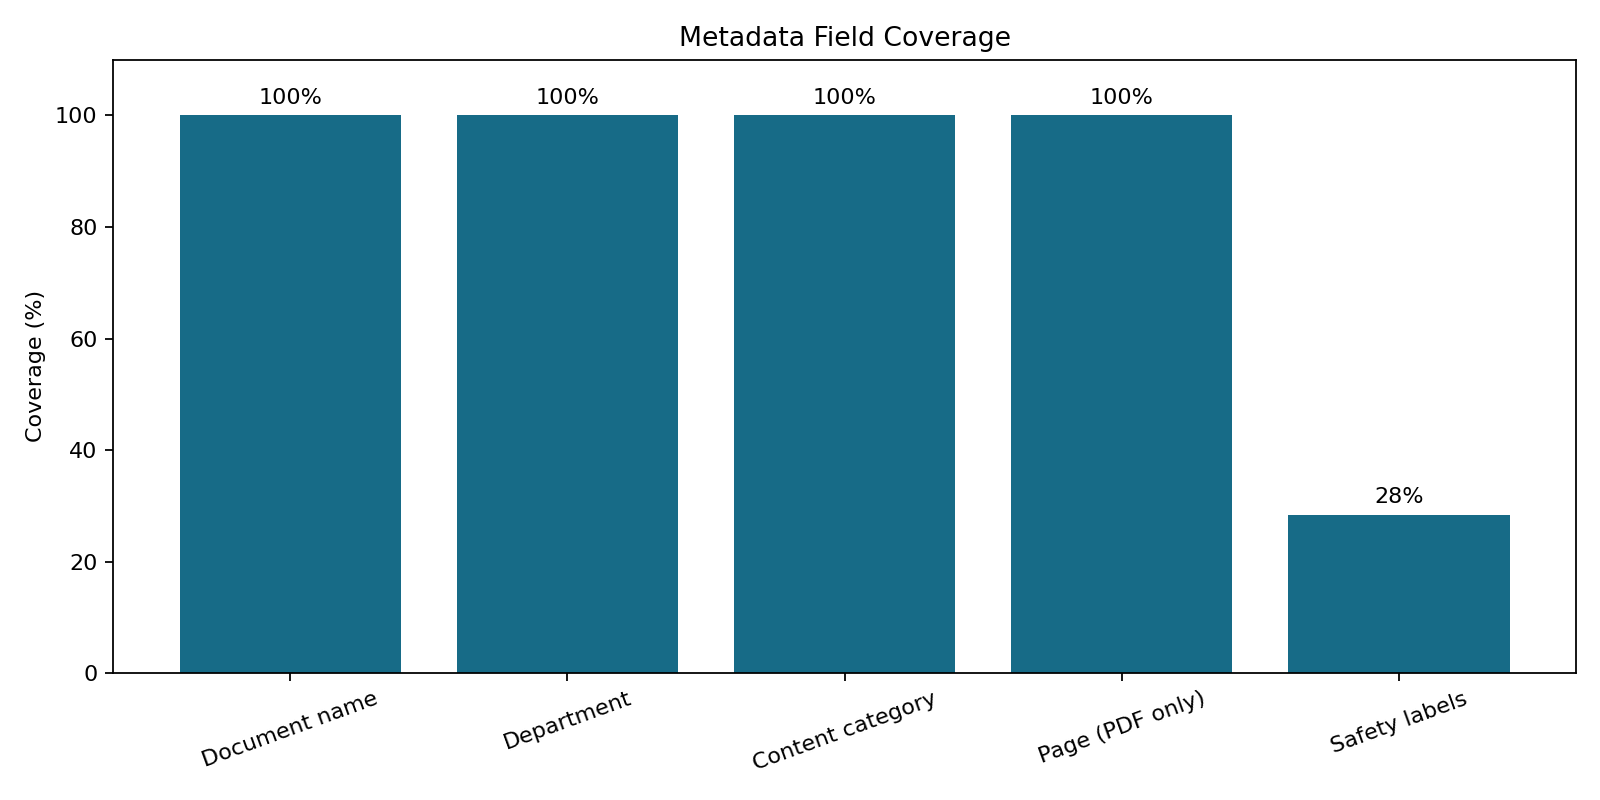

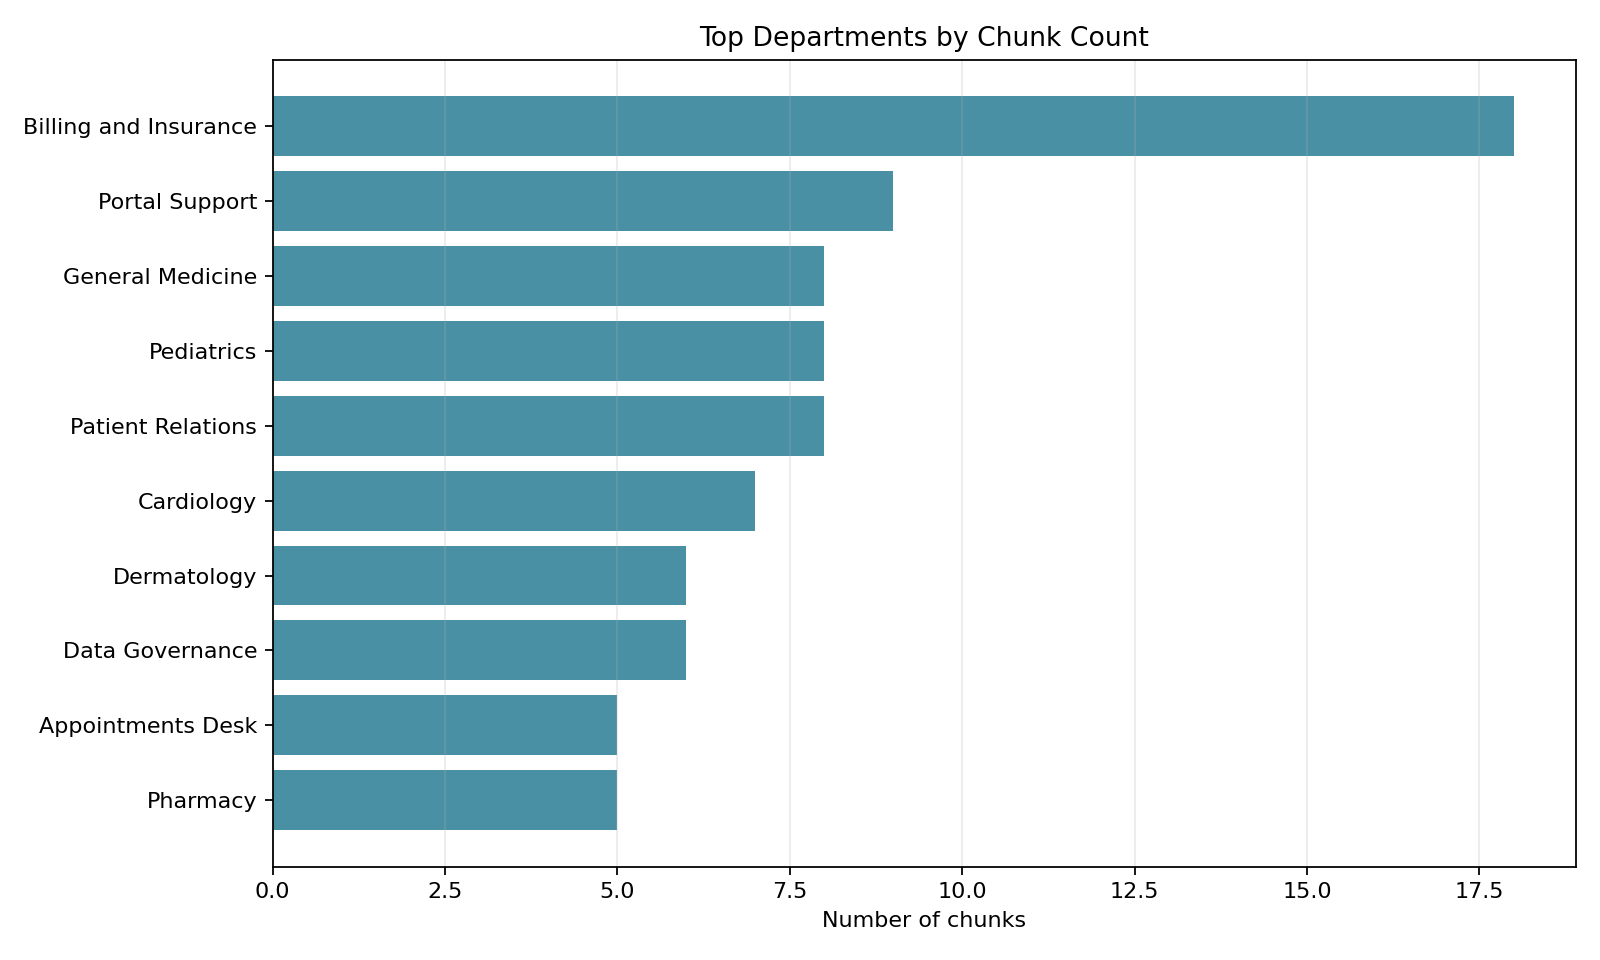

In [13]:
display(Image(filename=str(result.coverage_plot_path)))
display(Image(filename=str(result.department_plot_path)))


In [14]:
print("Output files:")
for output_name in report["output_files"]:
    output_path = PROCESSED_DATA_DIR / output_name
    print(f"- {output_path}: {output_path.stat().st_size:,} bytes")


Output files:
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\04_metadata.json: 87,902 bytes
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\04_enriched_chunks.json: 215,990 bytes
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\04_metadata_report.json: 1,647 bytes
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\04_metadata_audit.csv: 17,381 bytes
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\04_unresolved_metadata.json: 2 bytes
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\plots\04_metadata_field_coverage.png: 51,333 bytes
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_

## Notebook and Python module roles

The notebook imports the shared Python module, explains derivation choices, previews records, inspects the report, and displays plots. The Python module contains reusable derivation, PDF page matching, validation, reporting, plotting, file writing, and CLI behavior for automated workflows.

## Safety and next step

- Inferred fields include their method and confidence; they are never presented as source-authored facts.
- Safety labels support routing and evaluation only; they do not diagnose or score patient risk.
- Original chunk text and provenance remain unchanged in `04_enriched_chunks.json`.
- Continue with `05_create_embeddings.ipynb` using `04_enriched_chunks.json`.